# Etapa 2: Modelado con Validación Segura

**Autores:** Sergio Rada, Carlos Romero, Camilo Mujica y Natalia Alvarado.

Este notebook implementa el flujo completo de modelado para predecir falla cardíaca,
usando `Pipeline` y `GridSearchCV` para garantizar una validación sin data leakage.
Al final se exporta el mejor modelo para ser consumido por la API (Etapa 3).

## 1. Carga de librerías y datos

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, RocCurveDisplay
)

df = pd.read_csv("heart.csv")

## 2. División de datos ANTES del preprocesamiento

El split se hace sobre los datos crudos. Ninguna transformación ocurre antes de esta línea.
Esto garantiza que el escalado y la codificación solo aprendan del conjunto de entrenamiento.

In [2]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 3. Preprocesador con ColumnTransformer

Se define un `ColumnTransformer` que aplica:
- `MinMaxScaler` a las columnas numéricas
- `OneHotEncoder` a las columnas categóricas

Este objeto se incluirá como primer paso de cada `Pipeline`,
asegurando que el ajuste del escalador y el encoder ocurran
solo con datos de entrenamiento en cada fold de la validación cruzada.

In [3]:
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

preprocessor = ColumnTransformer([
    ("num", MinMaxScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## 4. Función de entrenamiento reutilizable

Encapsula la construcción del `Pipeline` y la búsqueda de hiperparámetros
con `GridSearchCV`. Recibe el modelo y su `param_grid` y devuelve el grid ajustado.

In [4]:
def train_pipeline(X_train, y_train, model, param_grid):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", model)
    ])
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid
# definición de modelos e hiperparámetros
modelos = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {"clf__C": [0.01, 0.1, 1, 10],
         "clf__solver": ["lbfgs", "liblinear"]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__max_depth": [None, 5, 10],
         "clf__min_samples_split": [2, 5]}
    ),
    "KNeighbors": (
        KNeighborsClassifier(),
        {"clf__n_neighbors": [3, 5, 7, 11],
         "clf__weights": ["uniform", "distance"]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {"clf__n_estimators": [100, 200],
         "clf__learning_rate": [0.05, 0.1],
         "clf__max_depth": [3, 5]}
    ),
    "SVC": (
        SVC(probability=True),
        {"clf__C": [0.1, 1, 10],
         "clf__gamma": [0.01, 0.1, 1],
         "clf__kernel": ["rbf", "linear"]}
    )
}

## 5. Entrenamiento y ranking comparativo

In [5]:
resultados = []
grids_entrenados = {} # diccionario para guardar los grids

for nombre, (modelo, param_grid) in modelos.items():
    print(f"Entrenando {nombre}...")
    grid = train_pipeline(X_train, y_train, modelo, param_grid)
    grids_entrenados[nombre] = grid

    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    auc     = roc_auc_score(y_test, y_proba)
    acc     = accuracy_score(y_test, y_pred)

    resultados.append({
        "Modelo":         nombre,
        "AUC":            round(auc, 4),
        "Accuracy":       round(acc, 4),
        "Mejor AUC CV":   round(grid.best_score_, 4),
        "Mejores params": grid.best_params_
    })
    print(f"  AUC: {auc:.4f} | Accuracy: {acc:.4f}")

ranking = (
    pd.DataFrame(resultados)
    .sort_values("AUC", ascending=False)
    .reset_index(drop=True)
)
ranking.index += 1

print("\n── Ranking comparativo ──")
print(ranking[["Modelo", "AUC", "Accuracy", "Mejor AUC CV"]].to_string())

Entrenando LogisticRegression...
  AUC: 0.9297 | Accuracy: 0.8913
Entrenando RandomForest...
  AUC: 0.9327 | Accuracy: 0.8967
Entrenando KNeighbors...


c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\MSI TRUE GAMING\miniconda3\envs\ml_venv\lib\subprocess.py", line 1

  AUC: 0.9382 | Accuracy: 0.9130
Entrenando GradientBoosting...
  AUC: 0.9342 | Accuracy: 0.8913
Entrenando SVC...
  AUC: 0.9289 | Accuracy: 0.8859

── Ranking comparativo ──
               Modelo     AUC  Accuracy  Mejor AUC CV
1          KNeighbors  0.9382    0.9130        0.9149
2    GradientBoosting  0.9342    0.8913        0.9236
3        RandomForest  0.9327    0.8967        0.9294
4  LogisticRegression  0.9297    0.8913        0.9234
5                 SVC  0.9289    0.8859        0.9213


## 6. Evaluación detallada del mejor modelo

Se selecciona el modelo con mayor AUC en el conjunto de prueba
y se generan: matriz de confusión y curva ROC.

In [6]:
mejor_nombre = ranking.iloc[0]["Modelo"]
mejor_grid   = grids_entrenados[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")
print(f"Mejores parámetros: {mejor_grid.best_params_}")

Mejor modelo: KNeighbors
Mejores parámetros: {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}


### 6.1 Matriz de confusión

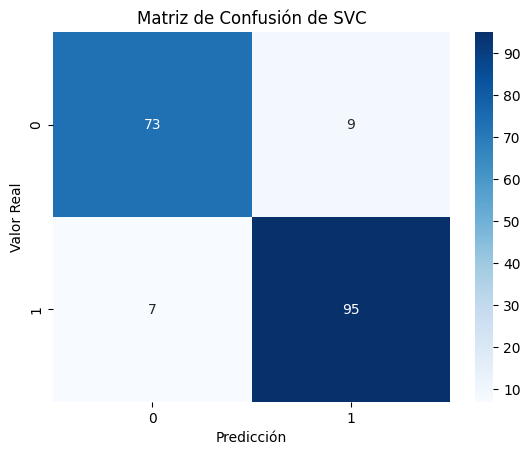

In [7]:
y_pred_mejor = mejor_grid.predict(X_test)

matrix = pd.DataFrame(confusion_matrix(y_test,y_pred_mejor))

sns.heatmap(matrix, annot=True, cmap='Blues', fmt='d')

plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión de '+nombre)
plt.show()

### 6.2 Curva ROC

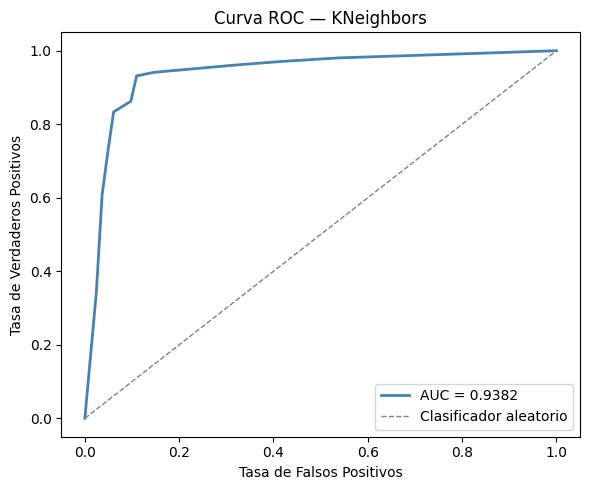

In [8]:
y_proba_mejor = mejor_grid.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba_mejor)
auc_mejor = roc_auc_score(y_test, y_proba_mejor)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc_mejor:.4f}")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title(f"Curva ROC — {mejor_nombre}")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.3 Comparación de curvas ROC — todos los modelos

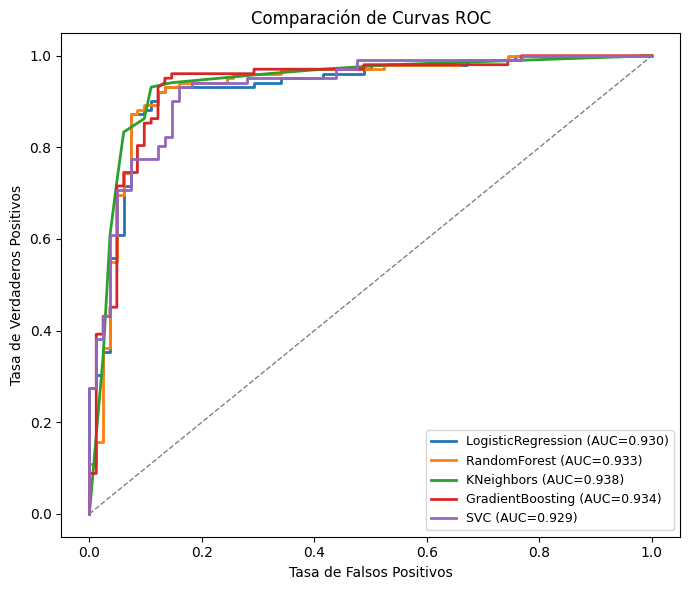

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

for nombre, grid in grids_entrenados.items():
    y_p = grid.predict_proba(X_test)[:, 1]
    fpr_i, tpr_i, _ = roc_curve(y_test, y_p)
    auc_i = roc_auc_score(y_test, y_p)
    ax.plot(fpr_i, tpr_i, lw=2, label=f"{nombre} (AUC={auc_i:.3f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Comparación de Curvas ROC")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 7. Exportación del mejor modelo

Se guarda el pipeline completo (preprocesador + clasificador) con `joblib`.
Este archivo será cargado directamente por la API en la Etapa 3,
sin necesidad de volver a entrenar ni replicar el preprocesamiento.

In [11]:
import joblib

joblib.dump(
    mejor_grid.best_estimator_,
    r"C:\Users\MSI TRUE GAMING\Desktop\mini_proy_2\heart-disease-mlops\app\model.joblib"
)

print(f"Modelo '{mejor_nombre}' exportado exitosamente")

Modelo 'KNeighbors' exportado exitosamente


In [12]:
print(X.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']


In [13]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
